# Final Model Comparison — Logistic Regression, Random Forest, XGBoost

This notebook trains all three final models **in a single session** so that comparison metrics, the ROC/PR curve overlay, and feature-importance comparisons are computed directly from live results rather than copied between notebooks. It also saves each trained model to disk so they can be loaded by the demonstration UI.

**Final model configuration decisions (see Hyperparameter Tuning notebook):**
- **Logistic Regression** — default hyperparameters retained. RandomizedSearchCV tuning produced identical performance to the defaults, so no change was justified.
- **Random Forest** — **tuned** hyperparameters used (`n_estimators=100, max_depth=15, min_samples_leaf=15, min_samples_split=5, max_features='log2'`). This tuned configuration improved ROC-AUC, Recall, and Average Precision simultaneously over the defaults, with no evidence of overfitting.
- **XGBoost** — **default** hyperparameters retained. Tuning improved Recall (+5.6% relative) but reduced ROC-AUC and Average Precision (-16% relative); since the two aggregate metrics both favoured the defaults, the default configuration was kept as the primary model.

## 1. Install & Import Libraries

Installs and imports the libraries required for data processing, model training, class imbalance handling, evaluation, visualisation and model persistence. Pandas and NumPy are used for data handling, Scikit-learn provides the preprocessing, modelling and evaluation tools, imbalanced-learn provides SMOTE and XGBoost provides the gradient boosting classifier. Joblib is used to save the trained models and preprocessing objects for later reuse. A saved_models directory is also created to store the final models, evaluation results, and figures.

In [1]:
!pip install xgboost imbalanced-learn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

os.makedirs('saved_models', exist_ok=True)
print('Libraries loaded')

Libraries loaded


## 2. Load & Preprocess Dataset

Loads the dataset and prepares it for model training. Negative values in session_length_in_minutes and device_distinct_emails_8w are clipped to zero because these values represent invalid or unknown observations in the dataset. Five categorical variables are converted into numerical values using Label Encoding so that they can be processed by the machine learning algorithms.

The target variable, fraud_bool, is separated from the predictor variables. The dataset is then divided into 80% training data and 20% test data using stratified sampling. Stratification preserves the original fraud-to-non-fraud class distribution in both subsets while random_state=42 ensures reproducibility. The feature order and encoder are also saved so that future predictions use the same input structure.

In [2]:
df = pd.read_csv('Base.csv') 
print(f'Shape: {df.shape}')

df['session_length_in_minutes'] = df['session_length_in_minutes'].clip(lower=0)
df['device_distinct_emails_8w'] = df['device_distinct_emails_8w'].clip(lower=0)

cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('fraud_bool', axis=1)
y = df['fraud_bool']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} rows | Test set: {X_test.shape[0]:,} rows')

# Save the feature column order — the UI will need this to build input vectors correctly
feature_columns = list(X.columns)
joblib.dump(feature_columns, 'saved_models/feature_columns.pkl')
joblib.dump(le, 'saved_models/label_encoder.pkl')
print('Preprocessing done')

Shape: (1000000, 32)
Training set: 800,000 rows | Test set: 200,000 rows
Preprocessing done


## 3. Train Logistic Regression (default hyperparameters)

Logistic Regression is used as the interpretable baseline model. Because Logistic Regression is sensitive to differences in feature scale, StandardScaler is fitted on the training data and used to transform both the training and test sets.
SMOTE is then applied only to the scaled training data to increase the representation of fraudulent observations while keeping the test set unchanged. This prevents synthetic samples from entering the final evaluation data. The model is trained using the resampled training set, after which class predictions and fraud probabilities are generated for the held-out test set. Both the trained Logistic Regression model and the fitted scaler are saved for later reuse.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote_lr = SMOTE(random_state=42, k_neighbors=5)
X_train_lr_sm, y_train_lr_sm = smote_lr.fit_resample(X_train_scaled, y_train)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
print('Training Logistic Regression...')
lr_model.fit(X_train_lr_sm, y_train_lr_sm)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
print('Logistic Regression trained')

joblib.dump(lr_model, 'saved_models/lr_model.pkl')
joblib.dump(scaler, 'saved_models/scaler.pkl')

Training Logistic Regression...
Logistic Regression trained


['saved_models/scaler.pkl']

## 4. Train Random Forest (tuned hyperparameters)

Random Forest is used as the non-linear bagging ensemble model. Unlike Logistic Regression, feature scaling is not required because decision-tree-based models make split decisions based on feature thresholds rather than feature magnitudes.

SMOTE is applied only to the training data to improve representation of the minority fraud class. The Random Forest classifier then uses the hyperparameters selected through the corrected leakage-free RandomizedSearchCV procedure. class_weight='balanced' is additionally used to give greater importance to the minority class during model fitting.

After training, the model generates both class predictions and predicted fraud probabilities for the same held-out test set used by the other models. The trained Random Forest model is then saved for later evaluation and demonstration.

In [4]:
smote_rf = SMOTE(random_state=42, k_neighbors=5)
X_train_rf_sm, y_train_rf_sm = smote_rf.fit_resample(X_train, y_train)

# Hyperparameters updated to the values selected by RandomizedSearchCV
# AFTER fixing the SMOTE data-leakage issue in the tuning notebook's CV
# (SMOTE moved inside an imblearn Pipeline so it is refit per training
# fold only). Final test-set performance is essentially unchanged from
# the pre-fix parameters, but these values are the ones the corrected,
# leakage-free search actually recommends.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=15,
    min_samples_split=5,
    max_features='log2',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
print('Training Random Forest (tuned)...')
rf_model.fit(X_train_rf_sm, y_train_rf_sm)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print('Random Forest trained')

joblib.dump(rf_model, 'saved_models/rf_model.pkl')

Training Random Forest (tuned)...
Random Forest trained


['saved_models/rf_model.pkl']

## 5. Train XGBoost (default hyperparameters)

XGBoost is used as the gradient-boosting model. Unlike Logistic Regression and Random Forest, SMOTE is not applied. Instead, class imbalance is handled using the scale_pos_weight parameter which is calculated from the ratio of legitimate to fraudulent observations in the training data.

The calculated value of approximately 89.67 increases the penalty associated with errors on the minority fraud class. The model is trained directly on the original training data without feature scaling because tree-based boosting models do not require standardisation. Class predictions and fraud probabilities are then generated for the held-out test set and the trained XGBoost model is saved for later use.

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
print('Training XGBoost (default)...')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print('XGBoost trained')

joblib.dump(xgb_model, 'saved_models/xgb_model.pkl')

scale_pos_weight = 89.67
Training XGBoost (default)...
XGBoost trained


['saved_models/xgb_model.pkl']

## 6. Consolidated Comparison Table

Evaluates all three trained models using the same held-out test set and the same performance metrics. The summarise() function calculates ROC-AUC, Average Precision, Precision, Recall, and F1-score for each model.

Using the same evaluation procedure allows a direct comparison between Logistic Regression, the tuned Random Forest and XGBoost. ROC-AUC is used to identify the model with the strongest overall discrimination while Average Precision, Precision, Recall and F1-score provide additional information about performance on the highly imbalanced fraud class.

The resulting comparison table is saved as a CSV file so that the same final values can be used consistently in the Results chapter.

In [7]:
def summarise(name, y_true, y_pred, y_prob):
    return {
        'Model'         : name,
        'ROC-AUC'       : round(roc_auc_score(y_true, y_prob), 4),
        'Avg Precision' : round(average_precision_score(y_true, y_prob), 4),
        'Precision'     : round(precision_score(y_true, y_pred), 4),
        'Recall'        : round(recall_score(y_true, y_pred), 4),
        'F1-Score'      : round(f1_score(y_true, y_pred), 4)
    }

comparison_df = pd.DataFrame([
    summarise('Logistic Regression', y_test, y_pred_lr, y_prob_lr),
    summarise('Random Forest (tuned)', y_test, y_pred_rf, y_prob_rf),
    summarise('XGBoost', y_test, y_pred_xgb, y_prob_xgb),
])

print('FINAL MODEL COMPARISON')
print('=' * 75)
print(comparison_df.to_string(index=False))
print('=' * 75)

best_model_name = comparison_df.loc[comparison_df['ROC-AUC'].idxmax(), 'Model']
print(f"\nHighest ROC-AUC: {best_model_name}")

comparison_df.to_csv('saved_models/final_comparison_table.csv', index=False)

FINAL MODEL COMPARISON
                Model  ROC-AUC  Avg Precision  Precision  Recall  F1-Score
  Logistic Regression   0.8626         0.1220     0.0412  0.7697    0.0782
Random Forest (tuned)   0.8349         0.0667     0.0645  0.4211    0.1119
              XGBoost   0.8937         0.1692     0.0595  0.7452    0.1102

Highest ROC-AUC: XGBoost


This table is the single source of truth for the Results chapter (Chapter 4), replacing the hardcoded/partial comparison tables in the individual model notebooks. All three models are trained and evaluated in this one session, on the identical train/test split, removing the risk of copy-paste errors between notebooks. XGBoost achieved the strongest overall predictive performance with the highest ROC-AUC (0.8937) and average precision (0.1692) among the three models. Logistic Regression achieved the highest fraud recall (0.7697) indicating that it detected a slightly larger proportion of fraudulent applications however its very low precision (0.0412) resulted in substantially more false-positive alerts. The tuned Random Forest achieved the highest F1-score (0.1119) but its recall (0.4211), ROC-AUC (0.8349) and average precision (0.0667) were considerably lower than those of XGBoost. Overall, XGBoost provides the strongest balance of ranking performance and minority-class detection and is therefore selected as the preferred model for this study.

## 7. ROC Curve Comparison (all three models)

Compares the ROC curves of all three models using their predicted fraud probabilities. The ROC curve plots the True Positive Rate against the False Positive Rate across a range of classification thresholds.

ROC-AUC summarises each model's overall ability to rank fraudulent observations above legitimate observations. A value closer to 1 indicates stronger discrimination, while the diagonal reference line represents the performance expected from a random classifier.

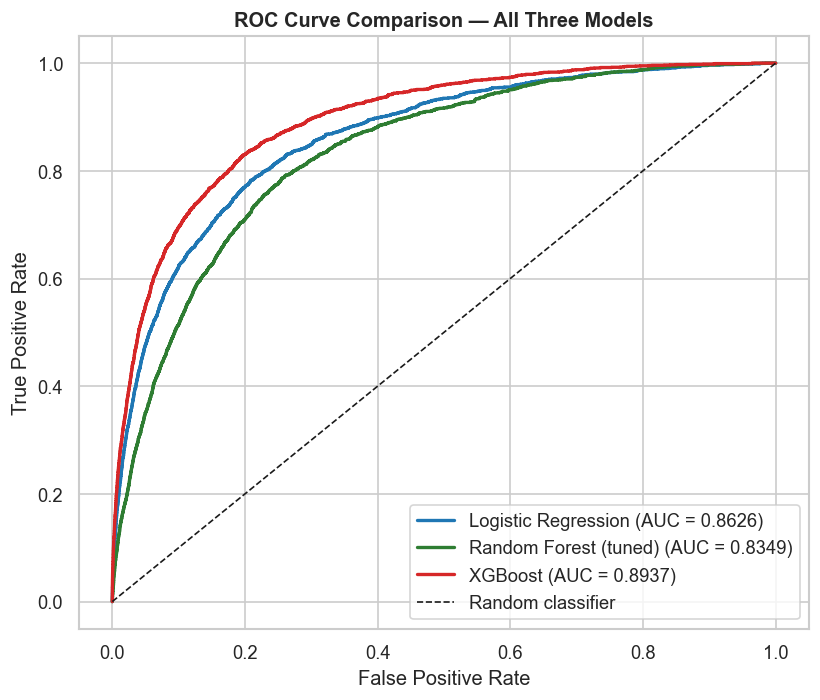

In [8]:
plt.figure(figsize=(7, 6))

for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#1f77b4'),
    ('Random Forest (tuned)', y_prob_rf, '#2E7D32'),
    ('XGBoost', y_prob_xgb, '#d62728'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Three Models', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('saved_models/roc_comparison.png', bbox_inches='tight')
plt.show()

XGBoost produces the highest ROC-AUC confirming that it provides the strongest overall discrimination between fraudulent and legitimate applications. Logistic Regression achieves the second-highest ROC-AUC while the tuned Random Forest produces the lowest ROC-AUC of the three models.

## 8. Precision-Recall Curve Comparison (all three models)

Evaluates the relationship between Precision and Recall across different classification thresholds. Precision measures the proportion of predicted fraud cases that are actually fraudulent while Recall measures the proportion of actual fraud cases that are successfully identified.

Because the BAF dataset is highly imbalanced, the Precision-Recall curve provides particularly useful information about minority-class performance. The horizontal baseline represents the underlying fraud prevalence in the test set allowing the models' performance to be compared with the expected result of an uninformative classifier.

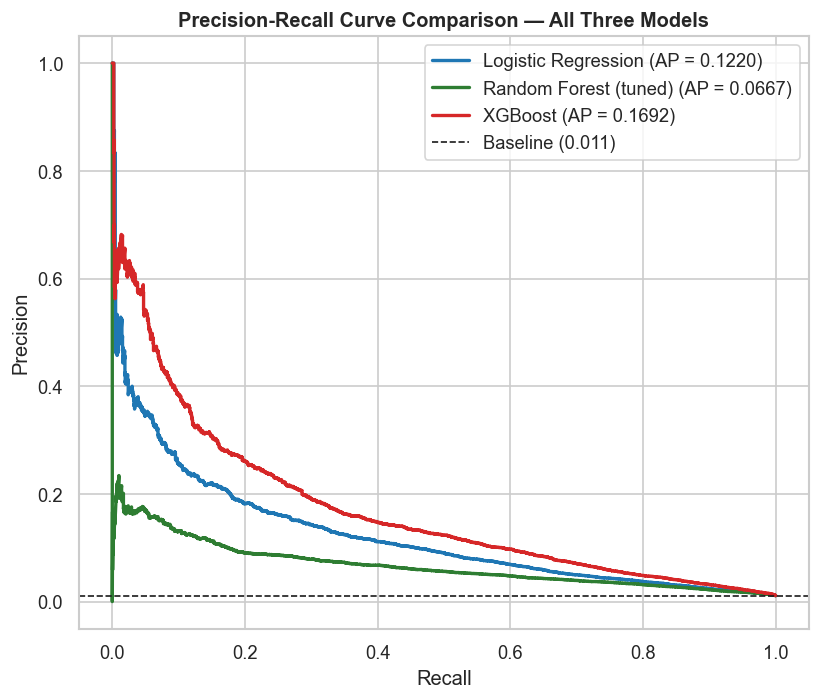

In [9]:
plt.figure(figsize=(7, 6))

for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#1f77b4'),
    ('Random Forest (tuned)', y_prob_rf, '#2E7D32'),
    ('XGBoost', y_prob_xgb, '#d62728'),
]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})', color=color, lw=2)

plt.axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label=f'Baseline ({y_test.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison — All Three Models', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('saved_models/pr_comparison.png', bbox_inches='tight')
plt.show()

XGBoost achieves the highest Average Precision (0.1692), followed by Logistic Regression (0.1220) and the tuned Random Forest (0.0667). This indicates that XGBoost provides the strongest overall Precision-Recall trade-off and performs best at identifying fraudulent applications while controlling the proportion of false-positive alerts.

## 9. Confusion Matrices (all three models)

Compares the classification error patterns of the three models using normalised confusion matrices. Each matrix shows the proportion of legitimate and fraudulent applications that are classified correctly or incorrectly.

Normalisation makes the models easier to compare despite the severe class imbalance. Particular attention is given to False Negatives where fraud is incorrectly classified as legitimate and False Positives where legitimate applications are incorrectly flagged as fraud.

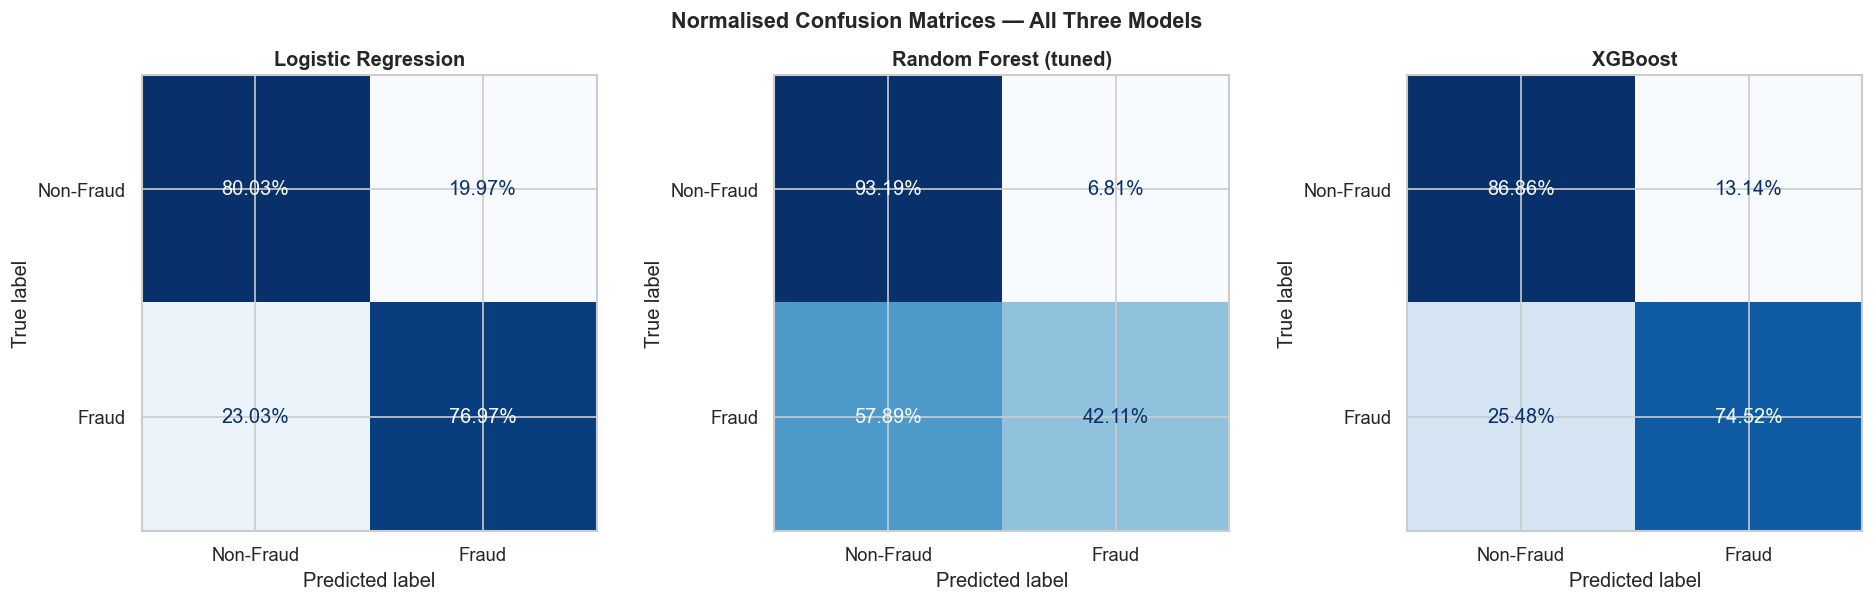

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest (tuned)', y_pred_rf),
    ('XGBoost', y_pred_xgb),
]):
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=['Non-Fraud', 'Fraud']).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format='.2%')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Normalised Confusion Matrices — All Three Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('saved_models/confusion_matrix_comparison.png', bbox_inches='tight')
plt.show()

Logistic Regression identifies the highest proportion of fraudulent applications which is consistent with its high Recall but it also produces a relatively large number of false-positive alerts. Random Forest is more conservative and generates fewer fraud predictions but this results in substantially more missed fraud cases.

XGBoost provides a stronger compromise between these two behaviours maintaining high fraud detection while avoiding some of the excessive false-positive predictions produced by Logistic Regression.

## 10. Saved Artefacts Summary

In [11]:
print('Saved to saved_models/ :')
for f in sorted(os.listdir('saved_models')):
    print(' -', f)
print()
print('lr_model.pkl, rf_model.pkl, xgb_model.pkl  — trained models for the demonstration UI')
print('scaler.pkl                                  — StandardScaler needed before calling lr_model')
print('label_encoder.pkl, feature_columns.pkl       — needed to encode UI inputs in the correct format')
print('final_comparison_table.csv                   — source of truth for Chapter 4 results table')
print('roc_comparison.png, pr_comparison.png,')
print('confusion_matrix_comparison.png              — figures for Chapter 4')

Saved to saved_models/ :
 - confusion_matrix_comparison.png
 - feature_columns.pkl
 - final_comparison_table.csv
 - label_encoder.pkl
 - lr_model.pkl
 - pr_comparison.png
 - rf_model.pkl
 - roc_comparison.png
 - scaler.pkl
 - xgb_model.pkl

lr_model.pkl, rf_model.pkl, xgb_model.pkl  — trained models for the demonstration UI
scaler.pkl                                  — StandardScaler needed before calling lr_model
label_encoder.pkl, feature_columns.pkl       — needed to encode UI inputs in the correct format
final_comparison_table.csv                   — source of truth for Chapter 4 results table
roc_comparison.png, pr_comparison.png,
confusion_matrix_comparison.png              — figures for Chapter 4


The Logistic Regression model requires the saved StandardScaler while the feature-column information and encoding objects help ensure that future inputs follow the same format used during training. The final comparison table and evaluation figures are also stored so that the Results chapter and any later demonstration interface use the same verified outputs.

## 11. Export Sample Cases for the Demonstration UI
A small set of test-set rows (with their true labels and original, human-readable feature values) is exported here so the demo UI can offer a few realistic pre-loaded examples without needing to load the full 1,000,000-row dataset.

In [ ]:

test_indices = X_test.index

fraud_idx    = y_test[y_test == 1].sample(n=5, random_state=42).index
nonfraud_idx = y_test[y_test == 0].sample(n=5, random_state=42).index
sample_idx   = list(fraud_idx) + list(nonfraud_idx)


sample_encoded = X_test.loc[sample_idx].copy()
sample_encoded['true_label'] = y_test.loc[sample_idx]
sample_encoded['case_id'] = [f'Fraud example {i+1}' for i in range(5)] + \
                             [f'Non-fraud example {i+1}' for i in range(5)]

sample_encoded.to_csv('saved_models/sample_cases.csv', index=False)
print(f'Exported {len(sample_encoded)} sample cases to saved_models/sample_cases.csv')
sample_encoded[['case_id', 'true_label']]

Exported 10 sample cases to saved_models/sample_cases.csv


,case_id,true_label
485548,Fraud example 1,1
736458,Fraud example 2,1
904244,Fraud example 3,1
268655,Fraud example 4,1
115573,Fraud example 5,1
216789,Non-fraud example 1,0
790717,Non-fraud example 2,0
817955,Non-fraud example 3,0
899048,Non-fraud example 4,0
858060,Non-fraud example 5,0
